**Problem definition**

The objective of this example is to demonstrate how a coupling between a SciML model and a numerical solver can help convergence.

We want to solve the following Poisson equation:

\begin{align}
\Delta u = f,
\end{align}

on a 2D square domain: $\Omega = [0,1]^2$.

The problem is formulated with finite differences, and solved by Jacobi iterations. The target function is:

\begin{align}
u(x,y) = \sin(\pi x) \sin(\pi y).
\end{align}

We train a convolutional neural network to assist the convergence of the numerical Jacobi solver. In this notebook, the CNN is trained to minimize the residuals of the Jacobi solver, after a random number of steps, on the same equation but with random source terms. Then, for inference, we run some iterations of Jacobi, and the CNN is applied once as a corrector. We then continue the jacobi iterations until convergence. We compare the convergence curves with and without the CNN correction, on the target function presented above, that has not been seen during training.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

torch.manual_seed(42)
np.random.seed(42)

Domain and solution:

In [2]:
N = 32                  # interior grid points per side
h = 1.0 / (N + 1)      # uniform grid spacing

coords = np.linspace(0, 1, N + 2)    # includes boundary nodes
X, Y   = np.meshgrid(coords, coords)

# Reference problem: exact solution u* = sin(pi x)sin(pi y)
u_star = np.sin(np.pi * X) * np.sin(np.pi * Y)
f_ref  = 2.0 * np.pi**2 * u_star # Interior source term associated with u*

Numerical solver and helpers:

In [3]:
def jacobi_step(u, f):
    """Jacobi solver step on interior points (boundary stays zero)."""
    u_new = u.copy()
    u_new[1:-1, 1:-1] = 0.25 * (
        u[:-2, 1:-1] + u[2:, 1:-1] +
        u[1:-1, :-2] + u[1:-1, 2:] +
        h**2 * f[1:-1, 1:-1]
    )
    return u_new

def residual(u, f):
    """r = f − Au,  where A is the 2D finite-difference Laplacian."""
    Au = np.zeros_like(u)
    Au[1:-1, 1:-1] = (
        4*u[1:-1, 1:-1]
        - u[:-2, 1:-1] - u[2:, 1:-1]
        - u[1:-1, :-2] - u[1:-1, 2:]
    ) / h**2
    return f - Au

def relative_error(u):
    return np.linalg.norm(u - u_star) / np.linalg.norm(u_star)

def run_jacobi(f, n_steps):
    """Jacobi solver, returns final u and per-step relative error history."""
    u = np.zeros((N+2, N+2))
    errors = []
    for _ in range(n_steps):
        u = jacobi_step(u, f)
        errors.append(relative_error(u))
    return u, errors

In [ ]:
def exact_solve(f):
    """
    Direct sparse solve for the Poisson equation on the N×N interior.
    Used to get ground-truth solutions for training problems.
    """
    n = N * N
    diag_main = 4.0 * np.ones(n)
    diag_off1 = -1.0 * np.ones(n - 1)
    diag_off1[np.arange(N - 1, n - 1, N)] = 0.0
    diag_offN = -1.0 * np.ones(n - N)

    A = (
        diags(
            [diag_offN, diag_off1, diag_main, diag_off1, diag_offN],
            [-N, -1, 0, 1, N],
            format="csc",
        )
        / h**2
    )

    u_int = spsolve(A, f[1:-1, 1:-1].ravel()).reshape(N, N)
    u = np.zeros((N + 2, N + 2))
    u[1:-1, 1:-1] = u_int
    return u


def random_smooth_rhs():
    """Random right hand side, sum of low-frequency sine modes."""
    f = np.zeros((N + 2, N + 2))
    for k in range(1, 5):
        for l in range(1, 5):
            f += np.random.randn() * np.sin(k * np.pi * X) * np.sin(l * np.pi * Y)
    return f

Data generation:

In [5]:
def generate_training_data(n_problems=500):
    """
    For each random problem:
      - compute the exact solution (direct sparse solver)
      - run a random number of Jacobi steps from zero
      - record (residual, error) on the interior, normalised per-sample
    The CNN is given as input the normalized residual, and predicts the associated correction.
    """
    print(f"Generating {n_problems} training points...")
    res_list, err_list = [], []

    for _ in range(n_problems):
        f        = random_smooth_rhs()
        u_ref    = exact_solve(f)
        n_warm   = np.random.randint(0, 60)
        u_approx, _ = run_jacobi(f, n_warm)

        r = residual(u_approx, f)[1:-1, 1:-1] # CNN input: residual
        e = (u_ref - u_approx)[1:-1, 1:-1]

        # per-sample normalisation
        scale = np.sqrt(np.mean(r**2)) + 1e-10
        res_list.append(r / scale)
        err_list.append(e / scale)
    print("Data created.")
    return (
        np.array(res_list, dtype=np.float32),
        np.array(err_list, dtype=np.float32),
    )

In [6]:
#| output: false
residuals, corrections = generate_training_data(n_problems=200)
X_train = torch.from_numpy(residuals[:, None])
Y_train = torch.from_numpy(corrections[:, None])

Generating 200 training points...
Data created.


CNN creation:

In [7]:
class ErrorCorrector(nn.Module):
    """
    CNN model:
      Input: residual field (N×N), Output:error correction field (N×N)
    Skip connection added for stability.
    """
    def __init__(self):
        Nloc = 32
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, Nloc, 3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(Nloc, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16,  1, 3, padding=1),
        )

    def forward(self, x):
        # Add skip connection
        return self.decoder(self.encoder(x)) + x

Training:

In [8]:
#| output: false
model     = ErrorCorrector()
optimiser = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimiser, step_size=30, gamma=0.5)
loss_fn   = nn.MSELoss()

dataset = torch.utils.data.TensorDataset(X_train, Y_train)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

### Start training:
n_epochs = 150
print(f"Training CNN for {n_epochs} epochs...")

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        pred  = model(xb)
        loss  = loss_fn(pred, yb)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{n_epochs}  loss = {epoch_loss/len(loader):.5f}")

Training CNN for 150 epochs...
  epoch  10/150  loss = 0.00621
  epoch  20/150  loss = 0.00385
  epoch  30/150  loss = 0.00252
  epoch  40/150  loss = 0.00162
  epoch  50/150  loss = 0.00125
  epoch  60/150  loss = 0.00100
  epoch  70/150  loss = 0.00081
  epoch  80/150  loss = 0.00073
  epoch  90/150  loss = 0.00066
  epoch 100/150  loss = 0.00059
  epoch 110/150  loss = 0.00052
  epoch 120/150  loss = 0.00050
  epoch 130/150  loss = 0.00048
  epoch 140/150  loss = 0.00047
  epoch 150/150  loss = 0.00044


In [9]:
### Hybrid solver: the CNN correction is applied after `cnn_at_step` iterations

def apply_cnn_correction(u, f):
    r     = residual(u, f)[1:-1, 1:-1]
    scale = np.sqrt(np.mean(r**2)) + 1e-10
    inp = torch.from_numpy((r / scale)[None, None].astype(np.float32))
    with torch.no_grad():
        correction = model(inp).squeeze().numpy() * scale
    u_new = u.copy()
    u_new[1:-1, 1:-1] += correction
    return u_new

def run_hybrid(f, n_steps, cnn_at_step=50):
    """Apply CNN correction only once at step `cnn_at_step`."""
    u      = np.zeros((N+2, N+2))
    errors = []

    for step in range(n_steps):
        u = jacobi_step(u, f)
        errors.append(relative_error(u))

        if step + 1 == cnn_at_step:
            u = apply_cnn_correction(u, f)
            errors[-1] = relative_error(u)
    return u, errors

Now we compare the numerical and hybrid solvers, on the target function:

In [10]:
# | output: false
n_steps = 500
cnn_at_step = 150
print("\nRunning solvers for comparison...")
u_jacobi, err_jacobi = run_jacobi(f_ref, n_steps)
u_hybrid, err_hybrid = run_hybrid(f_ref, n_steps, cnn_at_step=cnn_at_step)
print(f"  Jacobi only  — final error : {err_jacobi[-1]:.3e}")
print(f"  Jacobi + CNN — final error : {err_hybrid[-1]:.3e}")


Running solvers for comparison...
  Jacobi only  — final error : 1.027e-01
  Jacobi + CNN — final error : 2.741e-02


Convergence curves of the Jacobi and hybrid solvers:

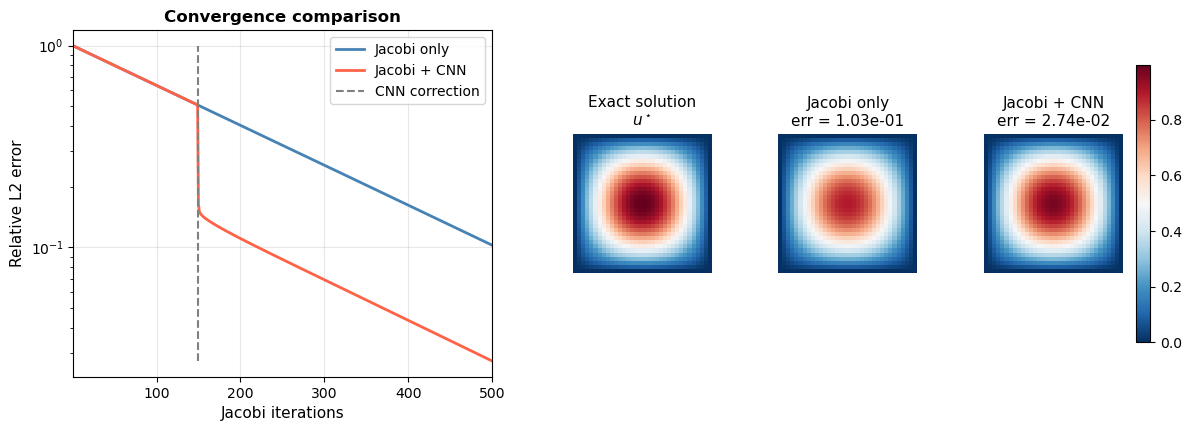

In [ ]:
iters = np.arange(1, n_steps + 1)

fig = plt.figure(figsize=(15, 4.5))
gs = gridspec.GridSpec(1, 4, width_ratios=[2.5, 1, 1, 1], wspace=0.35)

ax_conv = fig.add_subplot(gs[0])
ax_star = fig.add_subplot(gs[1])
ax_jac = fig.add_subplot(gs[2])
ax_hyb = fig.add_subplot(gs[3])

### Convergence curves
ax_conv.plot(iters, err_jacobi, label="Jacobi only", color="steelblue", linewidth=2)
ax_conv.plot(iters, err_hybrid, label=f"Jacobi + CNN", color="tomato", linewidth=2)
ax_conv.vlines(
    x=cnn_at_step - 1,
    ymin=np.min(err_hybrid),
    ymax=np.max(err_jacobi),
    linestyles="dashed",
    label="CNN correction",
    colors="grey",
    linewidth=1.5,
)

ax_conv.set_yscale("log")
ax_conv.set_xlabel("Jacobi iterations", fontsize=11)
ax_conv.set_ylabel("Relative L2 error", fontsize=11)
ax_conv.set_title("Convergence comparison", fontsize=12, fontweight="bold")
ax_conv.legend(fontsize=10)
ax_conv.grid(True, alpha=0.3)
ax_conv.set_xlim(1, n_steps)

### Solution fields
vmin, vmax = u_star.min(), u_star.max()
kwargs_plot = dict(vmin=vmin, vmax=vmax, cmap="RdBu_r", origin="lower")

ax_star.imshow(u_star, **kwargs_plot)
ax_star.set_title("Exact solution\n$u^\\star$", fontsize=11)
ax_star.axis("off")

ax_jac.imshow(u_jacobi, **kwargs_plot)
ax_jac.set_title(f"Jacobi only\nerr = {err_jacobi[-1]:.2e}", fontsize=11)
ax_jac.axis("off")

im = ax_hyb.imshow(u_hybrid, **kwargs_plot)
ax_hyb.set_title(f"Jacobi + CNN\nerr = {err_hybrid[-1]:.2e}", fontsize=11)
ax_hyb.axis("off")

plt.colorbar(im, ax=[ax_star, ax_jac, ax_hyb], shrink=0.8, pad=0.02)
plt.show()

The CNN corrector helps convergence, and can be applied after an arbitrary number of iterations. The special case of the accelerator, where the CNN prediction is applied before any step of the numerical solver, as initial guess, is further discussed in the notebook `hybrid_accelerator.ipynb`.